![Built with AI](https://img.shields.io/badge/Built%20with-AI-blue.svg)

# Laboratorio — Almacenamiento en disco y desempeño de I/O

Este notebook es la parte práctica del laboratorio de acceso a disco. Permite medir y comparar:

- acceso secuencial vs acceso aleatorio
- distintos tamaños de bloque
- resultados empíricos vs estimaciones teóricas

---

## Cómo usar este notebook

En este laboratorio encontrará tres tipos de secciones:

- **Ejecute esta celda:** contiene código listo para usar.
- **Analice:** debe interpretar los resultados obtenidos.
- **Conclusión:** debe redactar una respuesta breve con sus hallazgos.

> **Recomendación:** antes de ejecutar todo, revise la sección de
> **configuración** para ajustar el tamaño del archivo y el número de
> lecturas aleatorias según la capacidad de su equipo.

> **Recursos de apoyo:** las figuras de referencia para este laboratorio
> se encuentran en el `README.md` de la guía:
> - **fig1** — Jerarquía de memoria y latencias de referencia
> - **fig2** — Modelo de costo I/O y sus componentes
> - **fig3** — Comparación visual: acceso secuencial vs aleatorio
>
> Se recomienda tenerlas a mano mientras ejecuta el notebook.

## 0. Verificación del entorno

Ejecute la siguiente celda antes de continuar. Confirmará que todas
las librerías necesarias están disponibles en su entorno.

Si alguna librería aparece marcada con ✗, instálela con:

```bash
pip install nombre_libreria
```

En Google Colab todas las librerías ya están disponibles.

In [2]:
import sys
import importlib

librerias_requeridas = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
}

print(f'Python: {sys.version}')
print('-' * 40)

todo_ok = True
for nombre, modulo in librerias_requeridas.items():
    try:
        lib = importlib.import_module(modulo)
        version = getattr(lib, '__version__', 'versión no disponible')
        print(f'✓ {nombre} {version}')
    except ImportError:
        print(f'✗ {nombre} — NO encontrada. Instale con: pip install {nombre}')
        todo_ok = False

print('-' * 40)
if todo_ok:
    print('Entorno listo. Puede continuar con el laboratorio.')
else:
    print('Corrija las dependencias faltantes antes de continuar.')

Python: 3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]
----------------------------------------
✓ numpy 2.2.5
✓ pandas 3.0.1
✓ matplotlib 3.10.1
----------------------------------------
Entorno listo. Puede continuar con el laboratorio.


## 1. Objetivos del notebook

Al finalizar esta práctica debería poder:

1. Entender cómo afecta el patrón de acceso al rendimiento.
2. Medir tiempos de lectura secuencial y aleatoria.
3. Calcular throughput empírico.
4. Comparar mediciones con un modelo teórico simple de I/O.
5. Visualizar los resultados con gráficas automáticas.

In [3]:
import os
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Entorno listo.')

Entorno listo.


## 2. Recordatorio teórico

Antes de iniciar las mediciones, repase los conceptos clave que
usará a lo largo del experimento.

### Jerarquía de memoria y costo de acceso

Los dispositivos de almacenamiento tienen latencias muy distintas.
Un acceso a RAM toma nanosegundos; un acceso a disco puede tomar
milisegundos — una diferencia de hasta un millón de veces. Por eso
los sistemas están diseñados para minimizar los accesos a disco.

### Bloques de I/O

El disco no lee bytes individuales — lee **bloques completos**.
Incluso si un programa solicita 1 byte, el sistema transfiere todo
el bloque (típicamente 4 KB en sistemas operativos, 4–16 KB en
motores de bases de datos).

### Patrones de acceso

- **Secuencial:** los bloques se leen uno tras otro en posiciones
  contiguas. El número de accesos físicos al disco es mínimo (M ≈ 1).
- **Aleatorio:** cada bloque está en una posición distinta del disco.
  Cada acceso requiere posicionamiento independiente, por lo que M
  puede ser muy grande.

### Modelo de costo I/O

$$TotalTime = AccessLatency \times M + \frac{DataSize}{ScanThroughput}$$

- **AccessLatency:** tiempo para acceder al inicio de un bloque.
- **M:** número de accesos no contiguos al disco.
- **DataSize:** volumen total de datos a leer.
- **ScanThroughput:** velocidad de lectura sostenida del dispositivo.

> **Conexión con clase:** en las diapositivas se estudió el modelo
> detallado del HDD: $T_{access} = T_{seek} + T_{rotation} + T_{transfer}$.
> En este laboratorio, $AccessLatency$ agrupa $T_{seek}$ y $T_{rotation}$
> en un único valor promedio. Esta simplificación permite comparar
> tecnologías distintas (HDD, SSD, NVMe) con la misma fórmula.

## Punto de control 1 — Revisión conceptual

Antes de continuar, responda brevemente:

1. ¿Qué representa la latencia en este laboratorio?
2. ¿Qué representa el throughput?
3. ¿Por qué en acceso secuencial normalmente se asume que $M \approx 1$?
4. ¿Por qué en acceso aleatorio $M$ tiende a ser mayor?

> **Criterio mínimo:** cada respuesta debe tener al menos una oración
> propia. No copie definiciones — explíquelo con sus palabras.

### Respuestas

- **Respuesta 1**: La latencia representa el tiempo que transcurre desde que el sistema solicita un bloque de datos hasta que comienza a recibirlo; es decir, es el tiempo que tarda en ir a buscarlo, no en transferirlo. En una biblioteca, por ejemplo, sería el tiempo que transcurre desde que pido un libro hasta que la bibliotecaria lo encuentra y lo pone en el mostrador. El libro aún no está en mis manos, pero ya está listo para ser entregado.
  
  Ahora, en términos del hardware, este costo varía según el tipo de disco que tenga el dispositivo. Según lo visto en clase, en un HDD la latencia incluye el tiempo que tarda el brazo mecánico en moverse a la pista correcta ($T_{seek}$) más el tiempo de espera a que el plato rote hasta el sector indicado ($T_{rotation}$). En un SSD, como no hay partes móviles, simplemente se reduce al tiempo que tarda el controlador interno en procesar la solicitud.

- **Respuesta 2**: El throughput es la cantidad de datos que se transfieren por unidad de tiempo una vez que el sistema ya encontró el bloque de datos y comenzó a leerlo. Mide la velocidad de entrega de datos, sin tener en cuenta la latencia de posicionamiento previa. Continuando con el ejemplo de la biblioteca, una vez que la bibliotecaria ya tiene los libros sobre el mostrador, el throughput sería cuántos libros puede entregar por minuto. No importa cuánto tardó en buscarlos, sino qué tan rápido los entrega ahora que los tiene.

- **Respuesta 3**: En acceso secuencial se asume $M \approx 1$ porque todos los bloques están almacenados uno al lado del otro en el disco (en posiciones contiguas del disco), de modo que el sistema solo necesita localizar el punto de inicio una única vez y luego leer todo en fila, sin reposicionarse, sin interrupciones. En el ejemplo de la biblioteca equivaldría a buscar 5 libros que están en el mismo estante: voy al estante una sola vez y los tomo todos sin necesidad de moverme a otro lugar.
  
- **Respuesta 4**: En acceso aleatorio $M$ tiende a ser mayor porque cada bloque que se debe leer está en una posición distinta y no predecible del disco, por lo que el sistema tiene que reposicionarse cada que necesite leer un bloque. En la biblioteca equivaldría a que cada uno de esos 5 libros esté en un estante diferente del edificio: tengo que moverme 5 veces para encontrar cada estante donde está cada libro.

## 3. Configuración del experimento

Puede ajustar estos parámetros según el tiempo disponible y la capacidad del entorno.

In [4]:
# ==============================
# CONFIGURACIÓN GENERAL
# ==============================

DATA_DIR = Path('io_lab_data')
DATA_DIR.mkdir(exist_ok=True)

FILE_PATH = DATA_DIR / 'dataset.bin'

# Tamaño del archivo a generar.
# En Colab se recomienda entre 128 y 512 MB.
FILE_SIZE_MB = 256

# Tamaños de bloque a comparar
BLOCK_SIZES = [4 * 1024, 16 * 1024, 64 * 1024, 256 * 1024]

# Número de lecturas aleatorias por tamaño de bloque
RANDOM_READS = 4000

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Archivo:', FILE_PATH)
print('Tamaño objetivo (MB):', FILE_SIZE_MB)
print('Bloques a probar (bytes):', BLOCK_SIZES)
print('Número de lecturas aleatorias:', RANDOM_READS)

Archivo: io_lab_data\dataset.bin
Tamaño objetivo (MB): 256
Bloques a probar (bytes): [4096, 16384, 65536, 262144]
Número de lecturas aleatorias: 4000


## Punto de control 2 — Reflexión sobre la configuración

Observe los parámetros impresos por la celda anterior y responda:

1. **Tamaño del archivo:** ¿Es suficiente para superar la caché RAM de
   su equipo? Compare con los valores de RAM registrados en la Etapa 1
   de la guía.

2. **Tamaño de bloque:** Los tamaños evaluados (4 KB, 16 KB, 64 KB,
   256 KB) corresponden a tamaños típicos de páginas en sistemas
   operativos y motores de bases de datos. ¿Cuál esperaría que tuviera
   mejor rendimiento en acceso aleatorio y por qué?

3. **Entorno de ejecución:** ¿Está ejecutando en local o en Google Colab?
   Recuerde que en Colab los tiempos medidos corresponden al hardware de
   Google, no al suyo.

### Respuestas

- **Respuesta 1**: Mi equipo cuenta con 8 GB de RAM. Como el archivo de prueba pesa 256 MB, cabe perfectamente dentro de la memoria disponible, lo que significa que el sistema operativo podría guardalo en caché depués de la primera lectura y las lecturas posteriores podrían estar siendo atendidas desde la RAM en lugar del disco físico. En ese caso, los tiempos medidos reflejarían velocidads cercanas a las de la DRAM y no las del SSD NVMe real (~ 5 GB/s), lo que haría que los resultados fueran optimistas respecto al rendimiento real del disco.
  
  Para garantizar que las pruebas sí se realicen desde el disco físico, lo ideal sería trabajar con un archivo notablemente mayor que la RAM disponible (> 8 GB ), de modo que éste no quepa en la caché y el sistema se vea obligado a acceder al almacenamiento del disco en cada operación.
  
- **Respuesta 2**: De los 4 tamaños evaluados, se esperaría que el bloque de 256 KB tenga el mejor rendimiento en acceso aleatorio. La razón la podría demostrar desde el modelo teórico visto en clase:
  $$
  TotalTime =
  AccessLatency \times M +
  \frac{DataSize}{ScanThroughput}
  $$
  
  En acceso aleatorio $M$ es alto porque cada lectura obliga al disco a reposicionarse en una nueva ubicación, generando un costo $AccessLatency$ en cada acceso. Ese costo es fijo por acceso, independientemente de cuántos datos se lean en él; por ello, si en lugar de leer 4 KB por acceso se leen 256 KB, se obtienen 64 veces más datos pagando exactamente el mismo costo de posicionamiento, lo que maximiza el throughput efectivo por acceso.

- **Respuesta 3**: Estoy ejecutando de forma local, en mi propio equipo. Esto significa que los tiempos medidos corresponden al hardware real de mi máquina, específicamente a su disco (SSD NVMe) y a su memoria RAM (8 GB).

### Reinicio del experimento

Si desea cambiar el tamaño del archivo de prueba y repetir el
experimento desde cero, ejecute la siguiente celda antes de continuar.
Esto eliminará el archivo generado anteriormente y forzará su
recreación con los nuevos parámetros.

> **Nota:** en condiciones normales no es necesario ejecutar esta
> celda. Omítala si es la primera vez que corre el notebook.

In [ ]:
# ==============================
# REINICIO DEL EXPERIMENTO
# (opcional — solo si cambió FILE_SIZE_MB)
# ==============================

import shutil

RESET = False  # Cambie a True para eliminar el archivo de prueba

if RESET:
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
        DATA_DIR.mkdir(exist_ok=True)
        print(f'Carpeta {DATA_DIR} eliminada. El archivo se recreará en la siguiente sección.')
    else:
        print('No hay archivos previos que eliminar.')
else:
    print('RESET = False. No se eliminó ningún archivo.')
    print('Cambie RESET = True si desea repetir el experimento con nuevos parámetros.')

## 4. Crear el archivo de prueba

Este archivo simula datos almacenados en disco. Solo se crea si todavía
no existe o si su tamaño no coincide con la configuración actual.

In [6]:
def create_test_file(file_path: Path, size_mb: int, chunk_mb: int = 8) -> None:
    """Crea un archivo binario grande para pruebas de I/O.

    Parámetros:
        file_path: ruta del archivo a crear.
        size_mb: tamaño total del archivo en MB.
        chunk_mb: tamaño del bloque con el que se escribe el archivo.
    """
    target_size = size_mb * 1024 * 1024
    if file_path.exists() and file_path.stat().st_size == target_size:
        print('El archivo ya existe y tiene el tamaño esperado.')
        return

    print(f'Creando archivo de {size_mb} MB...')
    chunk_bytes = chunk_mb * 1024 * 1024
    remaining = target_size

    with open(file_path, 'wb') as f:
        while remaining > 0:
            current = min(chunk_bytes, remaining)
            f.write(os.urandom(current))
            remaining -= current

    print('Archivo creado correctamente.')


create_test_file(FILE_PATH, FILE_SIZE_MB)
print('Tamaño final del archivo (bytes):', FILE_PATH.stat().st_size)

Creando archivo de 256 MB...
Archivo creado correctamente.
Tamaño final del archivo (bytes): 268435456


## Analice

Después de crear el archivo, responda:

1. ¿Qué papel cumple este archivo dentro del experimento?
2. ¿Por qué es útil trabajar con un archivo relativamente grande?
3. ¿Qué cree que ocurriría si el archivo fuera demasiado pequeño?

> **Criterio mínimo:** la respuesta 3 debe mencionar explícitamente
> el concepto de caché del sistema operativo.

### Respuestas

- **Respuesta 1**: El archivo binario es el objeto central del experimento, pues sobre él se realizan todas las operaciones de lectura, tanto secuenciales como aleatorias. Sin un archivo real almacenado en el disco, no habría nada que medir y, por ende, el laboratorio no podría llevarse a cabo.
  
- **Respuesta 2**: Trabajar con un archivo relativamente grande (como  256 MB) en lugar de uno pequeño, es fundamental para que las mediciones reflejen el comportamiento real del disco y no el de la memoria. Cuando el archivo es lo suficientemente grande se reduce la probabilidad de que quepa por completo en la caché del sistema operativo, forzando al sistema a realizar las lecturas desde el disco físico en lugar de la memoria y permitiendo observar el impacto real de la latencia.

- **Respuesta 3**: Si el archivo fuera demasiado pequeño el sistema operativo lo cargaría completo en la caché RAM desde la primera lectura y, a partir de ese momento, todas las lecturas posteriores, incluyendo las aleatorias, serían atendidas directamente desde la RAM sin involucrar el disco físico en ningún momento. Como resultado, los tiempos medidos no reflejarían la latencia ni el throughput real del disco, sino los de la RAM, lo que invalidaría el análisis.

## 5. Funciones auxiliares de medición

In [7]:
def format_bytes(num_bytes: int) -> str:
    """Convierte un tamaño en bytes a una representación legible."""
    units = ['B', 'KB', 'MB', 'GB', 'TB']
    value = float(num_bytes)
    for unit in units:
        if value < 1024 or unit == units[-1]:
            return f'{value:.2f} {unit}'
        value /= 1024


def throughput_mib_s(total_bytes: int, elapsed_seconds: float) -> float:
    """Calcula throughput en MiB/s."""
    if elapsed_seconds <= 0:
        return float('inf')
    return (total_bytes / (1024 * 1024)) / elapsed_seconds


def sequential_read_measure(file_path: Path, block_size: int) -> dict:
    """Mide lectura secuencial del archivo completo."""
    total_bytes = 0
    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': math.ceil(total_bytes / block_size),
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }


def random_read_measure(file_path: Path, block_size: int, reads: int) -> dict:
    """Mide lectura aleatoria de bloques en posiciones dispersas."""
    file_size = file_path.stat().st_size
    max_offset = file_size - block_size
    if max_offset <= 0:
        raise ValueError('El archivo es más pequeño que el tamaño de bloque.')

    offsets = np.random.randint(0, max_offset + 1, size=reads)
    total_bytes = 0

    start = time.perf_counter()
    with open(file_path, 'rb', buffering=0) as f:
        for offset in offsets:
            f.seek(int(offset))
            chunk = f.read(block_size)
            total_bytes += len(chunk)
    elapsed = time.perf_counter() - start
    return {
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'total_bytes': total_bytes,
        'operations': reads,
        'elapsed_s': elapsed,
        'throughput_mib_s': throughput_mib_s(total_bytes, elapsed),
    }

## 6. Ejecutar experimentos empíricos

Se ejecutará la medición para cada tamaño de bloque, comparando acceso
secuencial y aleatorio.

In [8]:
results = []

for block_size in BLOCK_SIZES:
    print(f'\nProbando bloque = {format_bytes(block_size)}')

    seq_result = sequential_read_measure(FILE_PATH, block_size)
    rnd_result = random_read_measure(FILE_PATH, block_size, RANDOM_READS)

    results.append(seq_result)
    results.append(rnd_result)

    print(f"Secuencial -> tiempo: {seq_result['elapsed_s']:.4f} s, throughput: {seq_result['throughput_mib_s']:.2f} MiB/s")
    print(f"Aleatorio  -> tiempo: {rnd_result['elapsed_s']:.4f} s, throughput: {rnd_result['throughput_mib_s']:.2f} MiB/s")

df_empirical = pd.DataFrame(results)
df_empirical['block_size_kib'] = df_empirical['block_size_bytes'] / 1024
df_empirical


Probando bloque = 4.00 KB
Secuencial -> tiempo: 0.2617 s, throughput: 978.10 MiB/s
Aleatorio  -> tiempo: 0.0606 s, throughput: 258.01 MiB/s

Probando bloque = 16.00 KB
Secuencial -> tiempo: 0.1049 s, throughput: 2441.56 MiB/s
Aleatorio  -> tiempo: 0.0358 s, throughput: 1743.53 MiB/s

Probando bloque = 64.00 KB
Secuencial -> tiempo: 0.0766 s, throughput: 3343.78 MiB/s
Aleatorio  -> tiempo: 0.1016 s, throughput: 2461.11 MiB/s

Probando bloque = 256.00 KB
Secuencial -> tiempo: 0.0755 s, throughput: 3392.84 MiB/s
Aleatorio  -> tiempo: 0.2983 s, throughput: 3351.96 MiB/s


,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib
0,Secuencial,4096,268435456,65536,0.261733,978.097493,4.0
1,Aleatorio,4096,16384000,4000,0.060561,258.006456,4.0
2,Secuencial,16384,268435456,16384,0.104851,2441.557600,16.0
3,Aleatorio,16384,65536000,4000,0.035847,1743.530804,16.0
4,Secuencial,65536,268435456,4096,0.076560,3343.778287,64.0
5,Aleatorio,65536,262144000,4000,0.101580,2461.107124,64.0
6,Secuencial,262144,268435456,1024,0.075453,3392.840576,256.0
7,Aleatorio,262144,1048576000,4000,0.298333,3351.961299,256.0


## Análisis de resultados empíricos

Observe la tabla generada y responda:

1. ¿Cuál patrón de acceso fue más rápido para cada tamaño de bloque?
2. ¿El throughput cambió al aumentar el tamaño de bloque?
3. ¿En qué caso observó la mayor diferencia entre secuencial y aleatorio?

> **Criterio mínimo:** la respuesta 3 debe incluir valores numéricos
> concretos obtenidos de la tabla (throughput en MiB/s o tiempo en s).

### Respuesta

- **Respuesta 1**: En todos los tamaños de bloque el acceso secuencial superó al aleatorio en throughput:

| Tamaño del Bloque | Secuencial (MiB/s) | Aleatorio (MiB/s) | Factor |
| --- | --- | --- | --- |
| 4 KB | ~ 978.10 | ~ 258.01 | ×3.79 |
| 16 KB | ~ 2441.56 | ~ 1743.53 | ×1.40 |
| 64 KB | ~ 3343.78 | ~ 2461.11 | ×1.36 |
| 256 KB | ~ 3392.84 | ~ 3351.96 | ×1.01 |
  
  El patrón más relevante de esta tabla es la convergencia que se va alcanzado en ambos patrones de acceso conforme aumenta el tamaño del bloque. Con 4 KB el acceso secuencial fue casi 4 veces más rápido que el aleatorio, mientras que con 256 KB esa ventaja se redujo a prácticamente ×1, es decir, ambos patrones tuvieron un rendimiento casi idéntico en throughput.

  Esto indica que, aunque el acceso secuencial siempre mantiene ventaja, el acceso aleatorio mejora considerablemente cuando se utilizan bloques más grandes.

- **Respuesta 2:** Sí, el throughput cambió significativamente al aumentar el tamaño del bloque y lo hizo de manera diferente para cada patrón de acceso:

| Tamaño del Bloque | Secuencial (MiB/s) | Factor de Ventaja Respecto a 4 KB | Factor de Ventaja Respecto a 16 KB | Factor de Ventaja Respecto a 64 KB |
| --- | --- | --- | --- | --- |
| 4 KB | ~ 978.10 | - | - | - |
| 16 KB | ~ 2441.56 | ×2.50 | - | - |
| 64 KB | ~ 3343.78 | ×3.42 | ×1.37 | - |
| 256 KB | ~ 3392.84 | ×3.47 | ×1.39 | ×1.01 |
  
  En acceso secuencial, el throughput creció de ~ 978.10 MiB/s con bloques de 4 KB hasta ~ 3392.84 MiB/s con bloques de 256 KB, teniendo una mejora de aproximadamente ×3.47.

| Tamaño del Bloque | Aleatorio (MiB/s) | Factor de Ventaja Respecto a 4 KB| Factor de Ventaja Respecto a 16 KB | Factor de Ventaja Respecto a 64 KB |
| --- | --- | --- | --- | --- |
| 4 KB | ~ 258.01 | - | - | - |
| 16 KB | ~ 1743.53 | ×6.76 | - | - |
| 64 KB | ~ 2461.11 | ×9.54 | ×1.41 | - |
| 256 KB | ~ 3351.96 | ×12.99 | ×1.92 | ×1.36 |
  
  En acceso aleatorio el crecimiento fue aún más pronunciado, pues pasó de ~258.01 MiB/s con 4 KB hasta ~3351.96 MiB/s con 256 KB, teniendo una mejora de aproximadamente ×13. Esto ocurre porque cada acceso tiene un costo fijo de latencia, independientemente de cuántos datos se lean en él. Cuando se utilizan bloques pequeños, la transferencia de datos útiles es muy poca, por lo que el costo de latencia domina; en cambio, con bloques grandes, cada acceso transfiere más información, reduciendo el número total de accesos, aprovechando mejor cada operación y reduciendo el papel que tiene el costo fijo de latencia en el rendimiento.

  Como el acceso secuencial ya parte de una posición eficiente ($M \approx 1$), su margen de mejora es menor en comparación a el acceso aleatorio.

- **Respuesta 3:** 

| Tamaño del Bloque | Secuencial (MiB/s) | Aleatorio (MiB/s) | Diferencia Absoluta (MiB/s) | Factor | Tiempo Secuencial (s) | Tiempo Aleatorio (s) | Diferencia Absoluta Tiempos (s) |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 4 KB | ~ 978.10 | ~ 258.01 | 720.09 | ×3.79 | 0.2617 | 0.0606 | 0.2011 |
| 16 KB | ~ 2441.56 | ~ 1743.53 | 698.03 | ×1.40 | 0.1049 | 0.0358 | 0.0691 |
| 64 KB | ~ 3343.78 | ~ 2461.11 | 882.67 | ×1.36 | 0.0766 | 0.1016 | 0.025 |
| 256 KB | ~ 3392.84 | ~ 3351.96 | 40.88 | ×1.01 | 0.0755 | 0.2983 | 0.2228 |
  
  En términos de diferencia absoluta de throughput, el caso más extremo fue con bloques de 64 KB, donde el secuencial superó al aleatorio en 882.67 MiB/s. Sin embargo esta métrica no refleja bien la diferencia porque solo muestra cuánto más rápido fue el secuencial en números absolutos y no en proporción, que es lo que realmente permite comparar de manera general la ventaja entre ambos.

  Ahora, teniendo en cuenta esto, la mayor diferencia proporcional se observó con bloques de 4 KB, donde el acceso secuencial alcanzó 978.10 MiB/s frente a apenas de 258.01 MiB/s del aleatorio, resultando en un factor de ventaja de ×3.79. Aquí el costo de la latencia dominó completamente el tiempo del acceso aleatorio, ya que al ser bloques tan pequeños cada uno de los 4000 posicionamientos transfería muy pocos datos útiles, haciendo que el throughput efectivo fuera una fracción mínima del throughput máximo del equipo.


## 7. Modelo teórico de costo I/O

En esta sección se calculan los tiempos esperados según el modelo
simplificado visto en clase. Estos valores servirán como referencia
para comparar con sus mediciones empíricas.

### Parámetros del dispositivo teórico

Los parámetros a continuación representan un dispositivo de referencia.
Puede ajustarlos para modelar el comportamiento esperado de su equipo:

| Dispositivo | AccessLatency | ScanThroughput |
|---|---|---|
| SSD NVMe (defecto) | 10 µs | 5 GB/s |
| SSD SATA | 100 µs | 500 MB/s |
| HDD | 10 ms | 100 MB/s |

> **Nota:** el parámetro `AccessLatency` de este modelo corresponde
> a la suma de $T_{seek} + T_{rotation}$ del modelo de HDD visto en
> clase. Para un SSD no existe seek ni rotación, pero sí existe una
> latencia del controlador que cumple el mismo rol en la fórmula.
> Ajuste el dispositivo modelado según la tecnología registrada en
> su tabla de caracterización de la Etapa 1.

In [9]:
# ==============================
# PARÁMETROS TEÓRICOS
# ==============================

THEORY_DEVICE = {
    'name': 'SSD aproximado',
    'access_latency_s': 10e-6,
    'scan_throughput_bytes_s': 5 * (1024**3),
}

# Si quiere modelar un HDD, puede descomentar esto:
# THEORY_DEVICE = {
#     'name': 'HDD aproximado',
#     'access_latency_s': 10e-3,
#     'scan_throughput_bytes_s': 100 * (1024**2),
# }

print(THEORY_DEVICE)

{'name': 'SSD aproximado', 'access_latency_s': 1e-05, 'scan_throughput_bytes_s': 5368709120}


## Punto de control 3 — Modelo teórico elegido

Indique cuál dispositivo teórico usó para comparar sus resultados:

- Dispositivo modelado: SSD NVMe
- Latencia asumida: 10 µs / 1e-05 s
- Throughput asumido: 5 GB/s

Luego explique por qué ese modelo podría parecerse o no a su entorno real.

- **Respuesta:** Se eligió el modelo SSD NVMe porque es la tecnología de almacenamiento de mi equipo, lo que lo convierte en el punto de referencia más adecuado para contrastar los resultados experimentales con el comportamiento esperado.
  
  El throughput teórico calculado (~5118.97 MiB/s, equivalente a aproximadamente 5.37 GB/s) es consistente con los rangos típicos de este tipo de dispositivo. Al compararlo con el throughput empírico máximo obtenido en acceso secuencial (~3392.84 MiB/s con bloques de 256 KB), se observa que el rendimiento real se aproxima al teórico pero sin alcanzarlo, lo cual es esperable dado que el modelo representa condiciones ideales.
  
  Esta diferencia evidencia las limitaciones del modelo frente a un entorno real. Mientras que el modelo asume que la latencia y el throughput son constantes, en la práctica pueden variar dependiendo de la carga del sistema operativo, la ejecución de procesos en segundo plano y la forma en la que se gestionan las solicitudes de lectura. Adicionalmente, es importante considerar el efecto de la caché en memoria RAM, pues dado que el tamaño del archivo utilizado en el laboratorio es relativamente pequeño en comparación con la RAM disponible, es posible que algunas lecturas hayan sido desde la caché del sistema, reduciendo la latencia observada. Esto puede hacer que los resultados empíricos no reflejen completamente el comportamiento del disco físico.
  
  En conclusión, el modelo NVMe es una buena aproximación para representar el comportamiento esperado del sistema. Sin embargo, no produce completamente el entorno real debido a factores como la variabilidad del sistema y el uso de la caché, lo que explica las diferencias observadas entre los valores teóricos y los empíricos.

In [10]:
def theoretical_io_time(
    data_size_bytes: int,
    m_accesses: int,
    access_latency_s: float,
    scan_throughput_bytes_s: float
) -> float:
    """Aplica el modelo simplificado de costo I/O."""
    return access_latency_s * m_accesses + (data_size_bytes / scan_throughput_bytes_s)


theory_rows = []
file_size = FILE_PATH.stat().st_size

for block_size in BLOCK_SIZES:
    seq_data_size = file_size
    seq_m = 1
    seq_time = theoretical_io_time(
        data_size_bytes=seq_data_size,
        m_accesses=seq_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Secuencial',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': seq_time,
        'theoretical_throughput_mib_s': throughput_mib_s(seq_data_size, seq_time),
    })

    rnd_data_size = block_size * RANDOM_READS
    rnd_m = RANDOM_READS
    rnd_time = theoretical_io_time(
        data_size_bytes=rnd_data_size,
        m_accesses=rnd_m,
        access_latency_s=THEORY_DEVICE['access_latency_s'],
        scan_throughput_bytes_s=THEORY_DEVICE['scan_throughput_bytes_s'],
    )

    theory_rows.append({
        'pattern': 'Aleatorio',
        'block_size_bytes': block_size,
        'block_size_kib': block_size / 1024,
        'theoretical_elapsed_s': rnd_time,
        'theoretical_throughput_mib_s': throughput_mib_s(rnd_data_size, rnd_time),
    })

df_theory = pd.DataFrame(theory_rows)
df_theory

,pattern,block_size_bytes,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s
0,Secuencial,4096,4.0,0.050010,5118.976205
1,Aleatorio,4096,4.0,0.043052,362.935239
2,Secuencial,16384,16.0,0.050010,5118.976205
3,Aleatorio,16384,16.0,0.052207,1197.156753
4,Secuencial,65536,64.0,0.050010,5118.976205
5,Aleatorio,65536,64.0,0.088828,2814.423923
6,Secuencial,262144,256.0,0.050010,5118.976205
7,Aleatorio,262144,256.0,0.235313,4249.667995


## 8. Comparación entre resultados empíricos y teóricos

In [11]:
df_compare = df_empirical.merge(
    df_theory,
    on=['pattern', 'block_size_bytes', 'block_size_kib'],
    how='left'
)

df_compare['elapsed_ratio_empirical_vs_theoretical'] = (
    df_compare['elapsed_s'] / df_compare['theoretical_elapsed_s']
)

df_compare['throughput_ratio_empirical_vs_theoretical'] = (
    df_compare['throughput_mib_s'] / df_compare['theoretical_throughput_mib_s']
)

df_compare

,pattern,block_size_bytes,total_bytes,operations,elapsed_s,throughput_mib_s,block_size_kib,theoretical_elapsed_s,theoretical_throughput_mib_s,elapsed_ratio_empirical_vs_theoretical,throughput_ratio_empirical_vs_theoretical
0,Secuencial,4096,268435456,65536,0.261733,978.097493,4.0,0.050010,5118.976205,5.233605,0.191073
1,Aleatorio,4096,16384000,4000,0.060561,258.006456,4.0,0.043052,362.935239,1.406691,0.710888
2,Secuencial,16384,268435456,16384,0.104851,2441.557600,16.0,0.050010,5118.976205,2.096603,0.476962
3,Aleatorio,16384,65536000,4000,0.035847,1743.530804,16.0,0.052207,1197.156753,0.686628,1.456393
4,Secuencial,65536,268435456,4096,0.076560,3343.778287,64.0,0.050010,5118.976205,1.530896,0.653212
5,Aleatorio,65536,262144000,4000,0.101580,2461.107124,64.0,0.088828,2814.423923,1.143560,0.874462
6,Secuencial,262144,268435456,1024,0.075453,3392.840576,256.0,0.050010,5118.976205,1.508758,0.662797
7,Aleatorio,262144,1048576000,4000,0.298333,3351.961299,256.0,0.235313,4249.667995,1.267815,0.788758


## Análisis comparativo: teoría vs práctica

Interprete la tabla comparativa:

1. ¿Los tiempos empíricos son mayores o menores que los teóricos?
2. ¿En cuál patrón de acceso la teoría se aproxima mejor?
3. ¿Qué factores reales podrían explicar las diferencias?

> **Criterio mínimo:** la respuesta 3 debe mencionar al menos dos
> factores concretos (por ejemplo: caché del SO, temperatura,
> carga del sistema, tipo de disco).

### Respuestas

- **Respuesta 1:** La respuesta varía según el patrón de acceso y el tamaño del bloque:

| Tamaño del Bloque | Tiempo Empírico - Secuencial | Tiempo Teórico - Secuencial | Factor | Tiempo Empírico - Aleatorio | Tiempo Teórico - Aleatorio | Factor |
| --- | --- | --- | --- | --- | --- | --- |
| 4 KB | 0.2617 | 0.0500 | ×5.23 | 0.0606 | 0.0431 | ×1.41 |
| 16 KB | 0.1049 | 0.0500 | ×2.10 | 0.0358 | 0.0522 | ×0.69 |
| 64 KB | 0.0766 | 0.0500 | ×1.53 | 0.1016 | 0.0888 | ×1.14 |
| 256 KB | 0.0755 | 0.0500 | ×1.51 | 0.2983 | 0.2353 | ×1.27 |
  
  En acceso secuencial los tiempos empíricos fueron mayores que los teóricos en todos los tamaños de bloque, con factores que van desde ×5.23 con bloques de 4 KB hasta ×1.51 con bloques de 256 KB. Esto significa que el modelo subestima el tiempo real de operación secuencial, especialmente con bloques pequeños, donde la sobrecarga del sistema operativo por cada llamada de lectura es significativa frente al poco dato útil que se transfiere por operación.
  
  En acceso aleatorio la situación es mixta. Para bloques de 4 KB, 64 KB y 256 KB los tiempos empíricos fueron mayores que los teóricos, lo cual es esperable dado que el modelo no captura toda la complejidad real del sistema. Sin embargo, el caso más llamativo es el de 16 KB, donde el tiempo empírico (0.0358 s) fue menor que el teórico (0.0522 s), con un factor de ×0.69, lo que indica que el sistema respondió más rápido de lo predicho, probablemente por el efecto de la caché del sistema operativo en esa medición específica.

- **Respuesta 2:** Ignorando el caso de 16 KB aleatorio, el modelo teórico se aproxima mejor al acceso aleatorio con bloques grandes. Con bloques de 64 KB el factor fue de ×1.14 y con 256 KB apenas fue de ×1.27, diferencias relativamente pequeñas entre predicción y realidad. La razón se puede explicar directamente desde el modelo: 
  
  $$
  TotalTime =
  AccessLatency \times M +
  \frac{DataSize}{ScanThroughput}
  $$
  
  Con bloques grandes y $M = 4000$ accesos fijos, el término $\frac{DataSize}{ScanThroughput}$ crece y comienza a dominar el tiempo total, mientras que $AccessLatency \times M$ representa una fracción cada vez menor. El throughput es una propiedad física del equipo que el modelo captura bien, por eso la predicción mejora cuando ese término domina. Con bloques pequeños ocurre lo contrario, ya que se transfiere poco dato útil y la latencia domina el tiempo total, aumentando el costo y reduciendo el rendimiento.
  
  En acceso secuencial el modelo subestima el tiempo en todos los casos porque asume que el equipo opera siempre a su throughput máximo de forma sostenida, cuando en la práctica este umbral solo se alcanza con bloques grandes y condiciones ideales.

- **Respuesta 3:** Varios factores explican las diferencias entre la teoría y la práctica. El más directo es la caché del sistema operativo, ya que como el archivo de prueba pesa 256 MB y mi equipo dispone de 8 GB de RAM, el sistema pudo haber almacenado bloques del archivo en caché tras las primeras lecturas, atendiendo las siguientes desde la memoria en lugar del disco. Esto explica directamente el caso de 16 KB aleatorio, donde el tiempo empírico fue menor que el teórico.
  
  Un segundo factor es la sobrecarga de llamadas al sistema. Cada operación de lectura implica una llamada al sistema operativo con un costo fijo de procesamiento independiente del tamaño del bloque. Con bloques de 4 KB y 4000 accesos aleatorios se realizan 4000 llamadas al sistema, lo que deriva en una sobrecarga acumulada y por ende en un aumento del tiempo total. En cambio, con bloques más grandes el mismo número de llamadas transfiere más datos útiles, reduciendo la sobrecarga y acercando el resultado a modelo.

  Finalmente, la variabilidad del SSD introduce desviaciones que no se contemplan en el modelo. Por ejemplo, cuando se realizan muchas lecturas dispersas y casi inmediatas el controlador del SSD puede acumular solicitudes antes de responder, generando pequeñas esperas que aumentan la latencia efectiva y hacen que el tiempo total empírico supere al teórico.

## 9. Gráficas automáticas

Las siguientes gráficas se generan a partir de los resultados del
experimento y se guardan automáticamente en la carpeta `images/`
para que pueda incluirlas en su informe.

In [12]:
# ==============================
# CONFIGURACIÓN DE EXPORTACIÓN
# ==============================

IMAGES_DIR = Path('images')
IMAGES_DIR.mkdir(exist_ok=True)

print(f'Las gráficas se guardarán en: {IMAGES_DIR.resolve()}')

Las gráficas se guardarán en: C:\Users\Usuario\Documents\2026-1\ESTRUCTURAS DE DATOS Y LABORATORIO\LABORATORIOS\LABORATORIO 3\lab3-IO_performance-CarolinaGomez\images


Guardada: fig_throughput.png


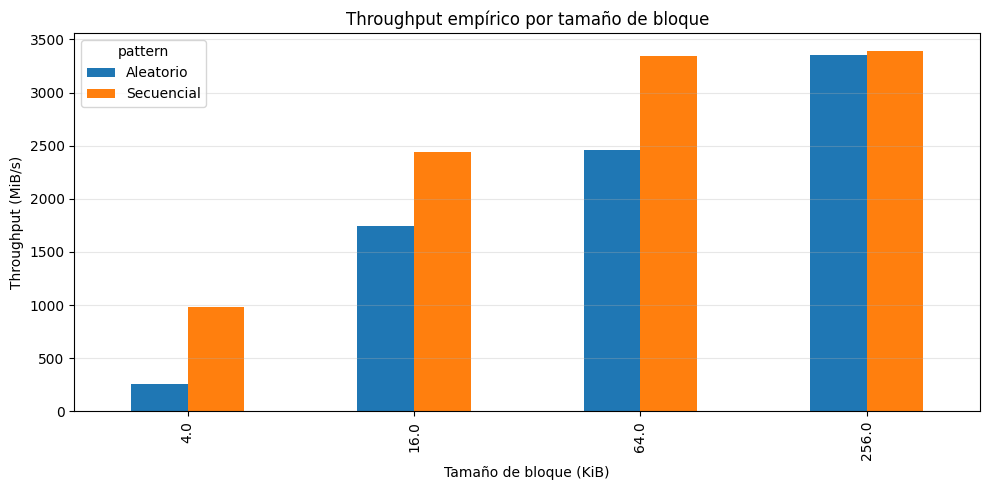

In [13]:
def plot_empirical_throughput(df: pd.DataFrame) -> None:
    """Grafica throughput empírico para secuencial y aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    ax = pivot.plot(kind='bar', figsize=(10, 5))
    ax.set_title('Throughput empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Throughput (MiB/s)')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_throughput.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_throughput.png')
    plt.show()


plot_empirical_throughput(df_empirical)

## Interprete la gráfica de throughput

Describa con sus palabras qué muestra esta gráfica:

- 1. ¿Qué barras son más altas?
- 2. ¿Qué significa eso en términos de rendimiento?
- 3. ¿Cuál patrón aprovecha mejor la lectura en bloques?

> **Criterio mínimo:** mencione al menos un tamaño de bloque específico
> y su valor de throughput observado.

### Respuesta

- **Respuesta 1:** Las barras de acceso secuencial son más altas que las de acceso aleatorio en todos los tamaños de bloque, con una caso bastante notable: en 256 KiB ambas barras se igualan casi por completo (~3392.84 MiB/s secuencial vs ~3351.96 MiB/s aleatorio), con una diferencia de apenas 40 MiB/s. La diferencia más llamativa ocurre en 4 KiB, donde el secuencial alcanzó ~978.10 MiB/s mientras que el aleatorio apenas llegó a ~258.01 MiB/s, una diferencia de casi 4 veces a favor del acceso secuencial.

- **Respuesta 2:** En términos de rendimiento esto significa que el acceso secuencial aprovecha mucho mejor la velocidad del disco, especialmente con bloques pequeños donde el costo de posicionamiento representa un proporción mayor del tiempo total de cada operación. Con bloques de 4 KiB, el acceso aleatorio transfiere muy pocos datos útiles por cada acceso, de modo que el costo fijo de latencia domina completamente el tiempo total, haciendo que el throughput efectivo sea una fracción mínima del máximo de mi equipo.

- **Respuesta 3:** Si se mide el aprovechamiento como la mejora relativa al aumentar el tamaño del bloque, el patrón que mejor aprovecha este aumento es el acceso aleatorio. Su throughput creció casi 13 veces al pasar de 4 KiB (258.01 MiB/s) a 256 KiB (3351.96 Mib/s), mientras que el acceso secuencial solo creció 3.5 veces en el mismo rango (de 978.10 MiB/s a 3392.84 MiB/s). Esto ocurre porque el secuencial ya partía de una posición eficiente, pues con $M \approx 1$ el costo de latencia era mínimo desde el inicio y había poco margen de mejora. El acceso aleatorio, en cambio, tenía mucho más margen de mejora porque su penalización con bloques pequeños era enorme. Al aumentar el tamaño del bloque el costo de posicionamiento no desaparece ni disminuye, pero si se amortiza gracias a la cantidad de datos útiles que se transfieren por operación, reduciendo así su impacto en el throughput y acercando progresivamente el rendimiento aleatorio al secuencial.
  
  Sin embargo, en términos de rendimiento absoluto, el acceso secuencial sigue siendo el que mejor aprovecha la lectura en bloques, ya que mantiene el mayor throughput en todos los tamaños de bloque y representa el caso más eficiente del uso de mi equipo.

Guardada: fig_tiempo_empirico.png


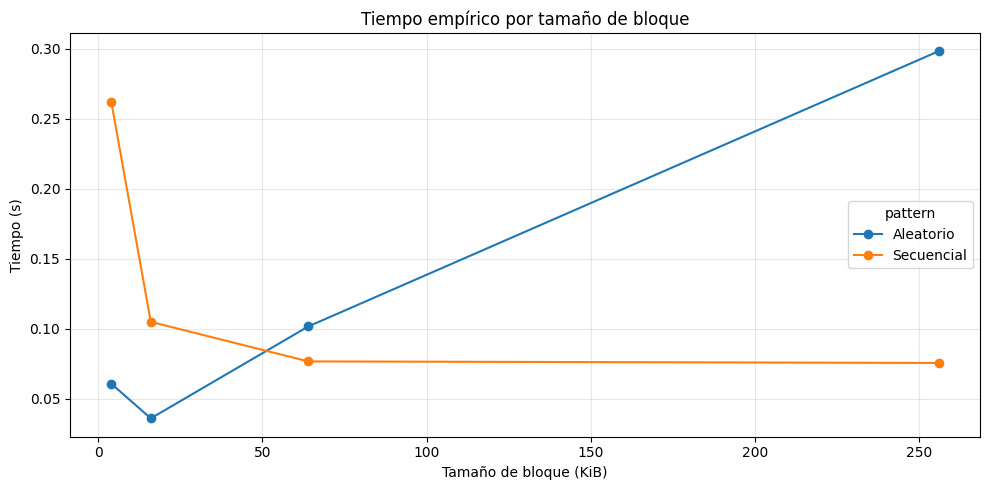

In [14]:
def plot_empirical_time(df: pd.DataFrame) -> None:
    """Grafica tiempo empírico por patrón de acceso."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='elapsed_s'
    ).sort_index()
    ax = pivot.plot(marker='o', figsize=(10, 5))
    ax.set_title('Tiempo empírico por tamaño de bloque')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Tiempo (s)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_tiempo_empirico.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_tiempo_empirico.png')
    plt.show()


plot_empirical_time(df_empirical)

## Interprete la gráfica de tiempo

Explique cómo cambia el tiempo total cuando cambia el tamaño de bloque.

> **Criterio mínimo:** compare el comportamiento de la curva secuencial
> con la aleatorio e indique en qué punto divergen más.

### Respuesta

Las dos curvas tienen comportamientos distintos, lo cual es una consecuencia directa de cómo funciona cada patrón de acceso.

La curva secuencial empieza alta en 4 KiB (0.262 s) y cae rápidamente hasta estabilizarse alrededor de 0.075 s a partir de los 64 KiB, punto desde el cual prácticamente no mejora más. Este comportamiento se explica porque en acceso secuencial el volumen total de datos leídos siempre es el mismo, independientemente del tamaño del bloque; lo que cambia es la eficiencia con la que se hacen esas lecturas. Con bloques pequeños el sistema realiza una enorme cantidad de llamadas individuales al sistema operativo, cada uno con su propia sobrecarga de procesamiento, mientras que con bloques más grandes se hacen muchas menos llamadas transfiriendo la misma cantidad total de datos, reduciendo esa sobrecarga acumulada. A partir de 64 KiB la curva se estabiliza porque el disco ya opera cerca de su velocidad máxima sostenida y aumentar el tamaño del bloque deja de producir mejoras significativas.

La curva aleatoria tiene un comportamiento un poco más complejo. Empieza en 4 KiB (0.061 s), desciende hasta su mínimo en 16 KiB (0.036 s) y luego sube de forma casi lineal hasta 0.298 s en 256 KiB. Ahora, para entender este comportamiento hay que tener en cuenta que en acceso aleatorio el volumen total de datos leídos no es fijo, sino que crece proporcionalmente con el tamaño del bloque: con $M = 4000$ accesos fijos,  los datos transferidos serían $4000 \times TamañoBloque$, entonces con bloques de 4 KiB se leen $4000 \times 4 KB = 16 MB$ en total, pero con bloques de 256 KiB se leen $4000 \times 256 KB = 102400 KB = 1024 MB = 1 GB$ en total, lo que equivaldría a 64 veces más datos con el mismo número de accesos. El tiempo total crece porque hay progresivamente más datos que transferir, aunque el número de accesos sea el mismo.

El punto donde las curvas divergen más es en 256 KiB, donde el acceso secuencial tarda apenas 0.075 s mientras que el aleatorio requiere 0.298 s, una diferencia de casi 4 veces en tiempo absoluto. Aquí se observa que mientras el acceso secuencial ya está completamente estabilizado en su velocidad máxima, el acceso aleatorio está cargando con el peso de transferir 1 GB de datos dispersos en 4000 accesos individuales.

Guardada: fig_tiempo_teoria_vs_practica_secuencial.png


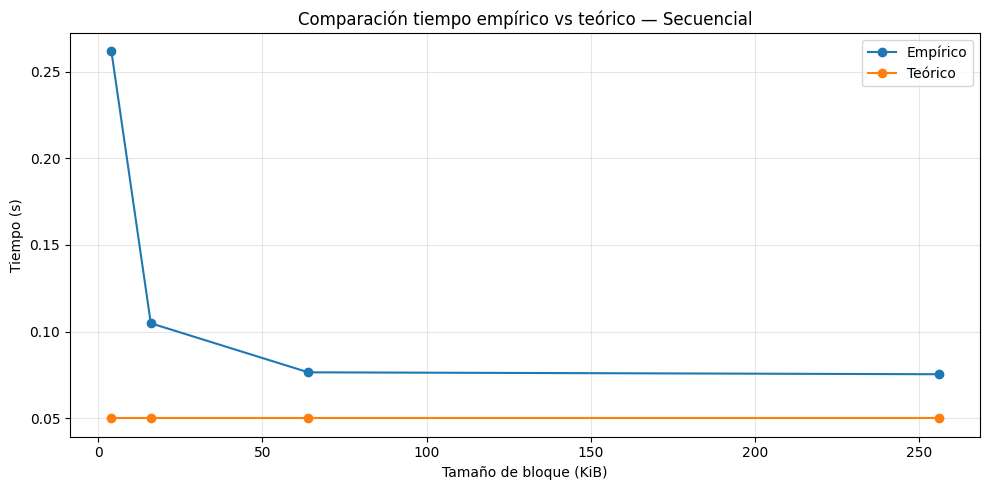

Guardada: fig_tiempo_teoria_vs_practica_aleatorio.png


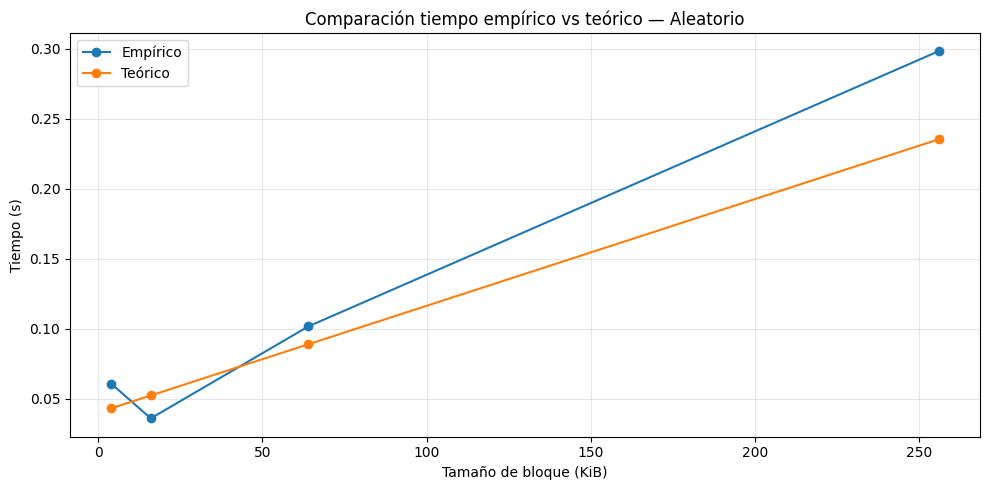

In [15]:
def plot_theory_vs_empirical(df: pd.DataFrame, pattern: str) -> None:
    """Compara tiempo empírico y teórico para un patrón dado."""
    subset = df[df['pattern'] == pattern].sort_values('block_size_kib')
    plt.figure(figsize=(10, 5))
    plt.plot(subset['block_size_kib'], subset['elapsed_s'],
             marker='o', label='Empírico')
    plt.plot(subset['block_size_kib'], subset['theoretical_elapsed_s'],
             marker='o', label='Teórico')
    plt.title(f'Comparación tiempo empírico vs teórico — {pattern}')
    plt.xlabel('Tamaño de bloque (KiB)')
    plt.ylabel('Tiempo (s)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    nombre = f'fig_tiempo_teoria_vs_practica_{pattern.lower()}.png'
    plt.savefig(IMAGES_DIR / nombre, dpi=150, bbox_inches='tight')
    print(f'Guardada: {nombre}')
    plt.show()


plot_theory_vs_empirical(df_compare, 'Secuencial')
plot_theory_vs_empirical(df_compare, 'Aleatorio')

## Interprete la comparación empírico vs teórico

Observe las curvas y responda:

1. ¿Las curvas tienen una tendencia similar?
2. ¿Dónde se separan más?
3. ¿Qué le sugiere eso sobre el modelo usado?

> **Criterio mínimo:** la respuesta 3 debe indicar si el modelo
> sobreestima o subestima el tiempo real, y proponer una razón.

### Respuesta

- **Respuesta 1:** En la gráfica de acceso secuencial las curvas tienen tendencias diferentes. La curva teórica es prácticamente una línea horizontal alrededor de 0.050 s en todos los tamaños de bloque, lo que indica que el modelo predice que el tiempo total depende únicamente del throughput del equipo y del tamaño fijo del archivo, sin importar el tamaño del bloque. La curva empírica, en cambio, empieza en 0.262 s con 4 KiB y cae abruptamente hasta estabilizarse cerca de 0.075 s a partir de 64 KiB. Ambas curvas convergen eventualmente, pero parten de puntos completamente distintos y nunca se cruzan.
  
  En la gráfica de acceso aleatorio ambas curvas comparten una tendencia más similar: las dos crecen al aumentar el tamaño del bloque. La diferencia es que la curva empírica desciende levemente de 4 KiB a 16 KiB antes de subir, mientras que la teórica crece de forma casi lineal desde el inicio.

- **Respuesta 2:** En la gráfica de acceso secuencial la separación máxima ocurre en 4 KiB, donde el tiempo empírico (0.262 s) es más de 5 veces mayor que el teórico (0.050 s). Esta brecha se reduce progresivamente hasta llegar a 256 KiB, donde el empírico (0.076 s) todavía supera al teórico (0.050 s) por un factor de ×1.51. La curva empírica desciende hacia la teórica, pero sin llegar a tocarla.
  
  En la gráfica de acceso aleatorio la separación más grande se da en 256 KiB, donde el empírico (0.298 s) supera al teórico (0.235 s) por un factor de ×1.27, la mayor brecha observada en ese patrón.

- **Respuesta 3:** A partir de las gráficas se observa que el modelo teórico no se ajusta de la misma manera para ambos patrones de acceso.
  
  En acceso secuencial el modelo tiende a subestimar el tiempo real en todos los casos. Esto se debe a que el modelo asume una transferencia continua e ideal a throughput máximo, sin contemplar la sobrecarga de cada llamada al sistema operativo ni la ineficiencia de trabajar con bloques pequeños, costos que en la práctica aumentan el tiempo total significativamente, especialmente con bloques de 4 KiB.
  
  En acceso aleatorio el modelo también subestima el tiempo real en la mayoría de los casos, porque no captura los costos adicionales por llamada al sistema operativo ni la variabilidad del SSD al atender muchas solicitudes dispersas casi inmediatas. La excepción es el bloque de 16 KB, donde el modelo sobreestima el tiempo, pues el empírico (0.036 s) fue menor que el teórico (0.052 s), lo que sugiere que la caché del sistema operativo intervino en esa medición, acelerando algunas lecturas por encima de lo que el disco físico habría entregado por sí solo.

Guardada: fig_speedup.png


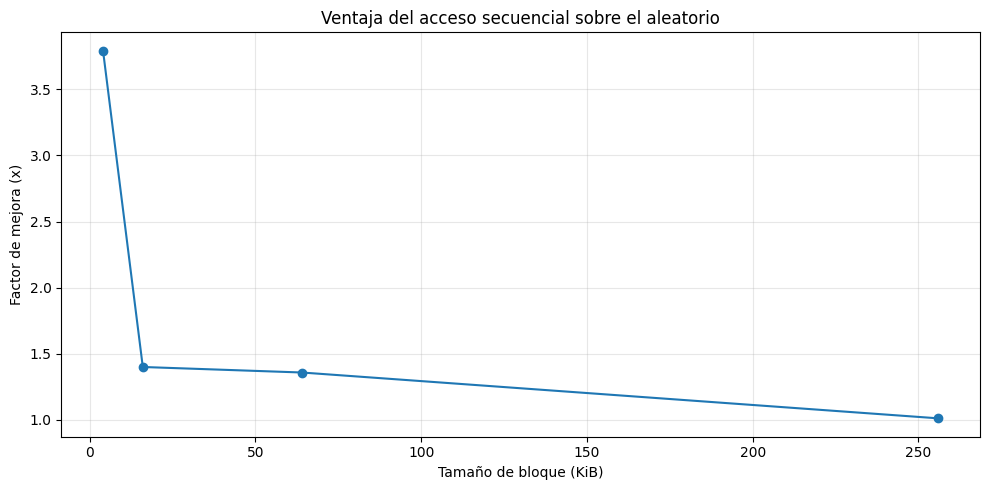

In [16]:
def plot_sequential_speedup(df: pd.DataFrame) -> None:
    """Grafica cuántas veces el acceso secuencial supera al aleatorio."""
    pivot = df.pivot(
        index='block_size_kib',
        columns='pattern',
        values='throughput_mib_s'
    ).sort_index()
    speedup = pivot['Secuencial'] / pivot['Aleatorio']
    ax = speedup.plot(marker='o', figsize=(10, 5))
    ax.set_title('Ventaja del acceso secuencial sobre el aleatorio')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Factor de mejora (x)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'fig_speedup.png', dpi=150, bbox_inches='tight')
    print('Guardada: fig_speedup.png')
    plt.show()


plot_sequential_speedup(df_empirical)

## Interprete la ventaja del acceso secuencial

La gráfica muestra cuántas veces el acceso secuencial supera al aleatorio.

- 1. ¿Cuál fue el mayor factor de mejora observado?
- 2. ¿Cómo cambia esa ventaja con el tamaño de bloque?
- 3. ¿Qué implicación tiene esto para el diseño de software?

> **Criterio mínimo:** incluya el valor numérico del mayor speedup
> observado y el tamaño de bloque en que ocurrió.

### Respuesta

- **Respuesta 1:** El mayor factor de mejora observado fue aproximadamente ×3.79 con bloques de 4 KiB, donde el acceso secuencial alcanzó 978.10 MiB/s frente a los apenas 258.01 MiB/s del acceso aleatorio. Esto significa que con el tamaño de bloque más pequeño evaluado, leer datos de forma contigua fue casi 4 veces más eficiente en throughput que leerlos de forma dispersa.

- **Respuesta 2:** La ventaja del acceso secuencial sobre el aleatorio cae drásticamente a medida que aumenta el tamaño del bloque:

| Tamaño del Bloque | Speedup |
| --- | --- |
| 4 KiB | ×3.79 |
| 16 KiB | ×1.40 |
| 64 KiB | ×1.36 |
| 256 KiB | ×1.01 |
  
  La caída más pronunciada ocurre entre 4 KiB y 16 KiB, donde el speedup pasa de ×3.79 a ×1.40. De ahí en adelante la caída continúa, pero de forma más gradual, hasta llegar ×1.01 en 256 KiB, punto en el que ambos patrones de acceso tienen un rendimiento prácticamente idéntico.
  
  Este comportamiento se explica directamente desde el modelo: con bloques más grandes cada acceso aleatorio recupera más datos útiles pagando el mismo costo fijo de $AccessLatency$, de modo que ese costo se amortiza y representa una fracción cada vez menor del tiempo total. Cuando el bloque es suficientemente grande, el throughput de transferencia domina completamente el tiempo en ambos patrones y la diferencia entre ellos prácticamente desaparece.

- **Respuesta 3:** Este experimento tiene implicaciones concretas y directas para el diseño de cualquier sistema que interactúe con almacenamiento en disco.
  
  La primera es que, siempre que sea posible, los datos que se acceden juntos deben almacenarse juntos físicamente en el disco. Un speedup de ×3.79 obtenido simplemente por cambiar el patrón de acceso, sin modificar el hardware, ni el algoritmo ni la cantidad de datos, demuestra que la organización física de los datos puede ser tan determinante para el rendimiento como el propio algoritmo que los procesa.
  
  La segunda es que, cuando el acceso aleatorio es inevitable, aumentar el tamaño del bloque es la forma más efectiva para recuperar el rendimiento. El salto de ×3.79 a ×1.40 entre 4 KiB y 16 KiB demuestra que incluso un ajuste moderado en el tamaño de bloque puede reducir drásticamente la penalización del acceso aleatorio.
  
  Como tercera y última implicación está que, en lugar de evitar el acceso aleatorio a toda costa, un sistema bien diseñado puede mitigar su penalización usando bloques grandes que amorticen el costo de posicionamiento, haciendo que la sobrecarga sea tolerable incluso en cargas de trabajo que tengan alta cantidad de accesos dispersos.

## 10. Resumen automático de resultados

In [17]:
summary_rows = []
for block_size in sorted(df_empirical['block_size_bytes'].unique()):
    seq = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Secuencial')
    ].iloc[0]
    rnd = df_empirical[
        (df_empirical['block_size_bytes'] == block_size) &
        (df_empirical['pattern'] == 'Aleatorio')
    ].iloc[0]
    summary_rows.append({
        'block_size_kib': block_size / 1024,
        'seq_time_s': seq['elapsed_s'],
        'rnd_time_s': rnd['elapsed_s'],
        'seq_throughput_mib_s': seq['throughput_mib_s'],
        'rnd_throughput_mib_s': rnd['throughput_mib_s'],
        'seq_vs_rnd_speedup': (
            seq['throughput_mib_s'] / rnd['throughput_mib_s']
            if rnd['throughput_mib_s'] > 0 else np.nan
        ),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,block_size_kib,seq_time_s,rnd_time_s,seq_throughput_mib_s,rnd_throughput_mib_s,seq_vs_rnd_speedup
0,4.0,0.261733,0.060561,978.097493,258.006456,3.790981
1,16.0,0.104851,0.035847,2441.557600,1743.530804,1.400352
2,64.0,0.076560,0.101580,3343.778287,2461.107124,1.358648
3,256.0,0.075453,0.298333,3392.840576,3351.961299,1.012196


## Conclusión final

Redacte una conclusión de entre 8 y 12 líneas que integre los
siguientes elementos. Recuerde que esta conclusión también formará
parte de su informe en el `README.md` de entrega.

Su conclusión debe responder, en prosa continua y con sus propias
palabras, las siguientes preguntas:

- ¿Cómo se almacena la información en disco y por qué eso importa?
- ¿Por qué el acceso secuencial y el aleatorio tienen desempeños
  tan distintos, incluso en un SSD?
- ¿Qué tan bien predijo el modelo teórico el comportamiento real
  de su equipo?
- ¿Qué decisión de diseño tomaría en un sistema real con base en
  lo que midió?

> **Criterio mínimo:** la conclusión debe incluir al menos un valor
> numérico concreto de sus resultados (por ejemplo, el factor de
> speedup o el throughput secuencial medido) y conectarlo con uno
> de los conceptos teóricos del curso.

### Conclusión

La información en disco no se accede byte por byte, sino por bloques completos y la forma en que esos bloques están distribuidos determinan la eficiencia del sistema. Cuando los datos son contiguos, el disco solo necesita posicionarse una única vez ($M \approx 1$) y leer todo en orden, mientras que cuando están dispersos, cada bloque exige un posicionamiento independiente.

Esto explica por qué el patrón de acceso sigue importando incluso en un SSD: con bloques de 4 KiB el acceso secuencial fue ×3.79 veces más eficiente que el aleatorio (978.10 MiB/s vs 258.01 MiB/s). Esa brecha se cerró progresivamente al aumentar el tamaño del bloque, hasta desaparecer en 256 KiB (speedup de ×1.01), porque bloques más grandes amortizan el costo fijo de posicionamiento entre más datos útiles tengan.
 
El modelo teórico capturó bien la tendecia general, pero sobreestimó el rendimiento real (predijo tiempos menores a los medidos) especialmente en el acceso secuencial con bloques pequeños, donde el empírico fue aproximadamente 5 veces mayor que el teórico.

Con base en estos resultados, en un sistema real priorizaría almacenar juntos los datos que se consultan juntos, para garantizar $M \approx 1$, y, cuando el acceso aleatorio sea inevitable, trabajar con bloques más grandes que amorticen el costo de cada posicionamiento. 

## 11. Preguntas de cierre

Responda en el `README.md` de su repositorio de entrega, apoyándose
en los resultados del experimento.

1. **Comparación de patrones:** Con base en sus mediciones, ¿cuántas
   veces más rápido fue el acceso secuencial respecto al aleatorio en
   su equipo? ¿Ese resultado era el esperado según la teoría?

2. **Efecto del tamaño de bloque:** ¿Qué ocurrió con el throughput del
   acceso aleatorio a medida que aumentó el tamaño de bloque?
   ¿Por qué cree que sucede eso?

3. **Teoría vs práctica:** Identifique un caso en sus resultados donde
   la medición empírica se alejó del modelo teórico. ¿A qué factor
   atribuye esa diferencia?

4. **Tipo de disco:** Compare sus resultados con los valores de referencia
   de la tabla de la guía. ¿Su equipo se comportó como un HDD, un SSD
   SATA o un SSD NVMe?

5. **Aplicación práctica:** Imagine que debe almacenar una tabla de
   estudiantes con 1 millón de registros. Con base en lo que midió,
   ¿preferiría leerla toda de forma secuencial o acceder a registros
   individuales de forma aleatoria? ¿Por qué?

## 12. Extensiones sugeridas

Si desea profundizar, puede ampliar el experimento de las siguientes formas:

- Repetir el experimento varias veces y promediar los resultados.
- Comparar lectura y escritura.
- Medir sobre SSD local vs disco de red.
- Cambiar el tamaño del archivo y observar el efecto en la caché.
- Comparar caché caliente vs caché fría ejecutando el benchmark dos veces seguidas.